<a href="https://colab.research.google.com/github/Rayudu-Somisetty/deep_learning_lab_tasks/blob/main/and_gate_hard_coded_weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AND GATE SINGLE PERCEPTRON HARD-CODED WEIGHTS
------------------------------------------------------------
Weights: w0 = 1.0, w1 = 1.0
Bias: b = -1.5
Equation: 1.0 * x1 + 1.0 * x2 + -1.5 > 0 => output = 1

PREDICTIONS
Input: (0, 0) | Linear output: -1.50 | Predicted: 0 | Actual: 0
Input: (0, 1) | Linear output: -0.50 | Predicted: 0 | Actual: 0
Input: (1, 0) | Linear output: -0.50 | Predicted: 0 | Actual: 0
Input: (1, 1) | Linear output: 0.50 | Predicted: 1 | Actual: 1


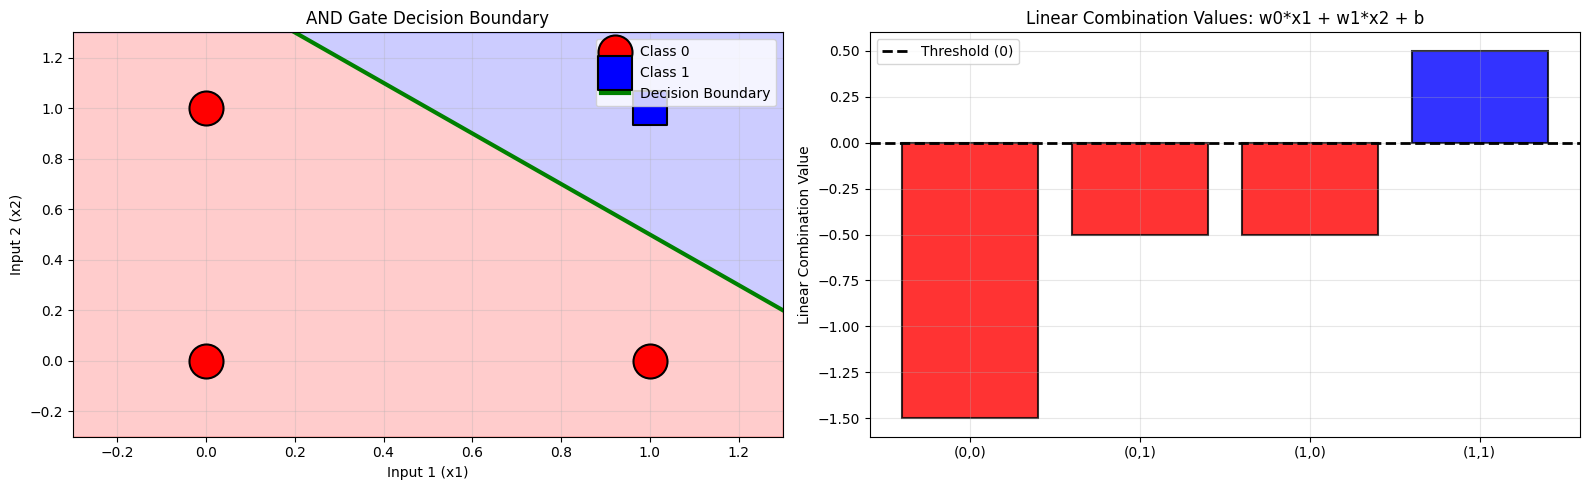


VERIFICATION RESULTS
Decision boundary equation: w0*x1 + w1*x2 + b = 0 => x2 = (-b - w0*x1) / w1
Input (0, 0): z = -1.50, Classified as Class 0 (<=0)
Input (0, 1): z = -0.50, Classified as Class 0 (<=0)
Input (1, 0): z = -0.50, Classified as Class 0 (<=0)
Input (1, 1): z = 0.50, Classified as Class 1 (>0)

Point positions relative to decision boundary:
Point (0, 0): Value = -1.500 => Below (Class 0)
Point (0, 1): Value = -0.500 => Below (Class 0)
Point (1, 0): Value = -0.500 => Below (Class 0)
Point (1, 1): Value = 0.500 => Above (Class 1)


In [1]:
#AND gate hard coded weights.

import numpy as np
import matplotlib.pyplot as plt

# Define 1D input arrays directly
X1 = np.array([0, 0, 1, 1])
X2 = np.array([0, 1, 0, 1])

# Define labels for AND gate output
y = np.array([[0], [0], [0], [1]])

print("AND GATE SINGLE PERCEPTRON HARD-CODED WEIGHTS")
print("-" * 60)

# Hard-coded weights and bias for AND gate perceptron
w0 = 1.0   # weight for X1
w1 = 1.0   # weight for X2
b = -1.5   # bias

print(f"Weights: w0 = {w0:.1f}, w1 = {w1:.1f}")
print(f"Bias: b = {b:.1f}")
print(f"Equation: {w0} * x1 + {w1} * x2 + {b} > 0 => output = 1")

# Step function (activation function)
def step_function(x):
    return 1 if x > 0 else 0

# Perceptron prediction using formula directly
def perceptron_predict(X1, X2, w0, w1, b):
    linear = w0 * X1 + w1 * X2 + b
    predictions = np.array([step_function(z) for z in linear])
    return linear.reshape(-1, 1), predictions.reshape(-1, 1)

print("\nPREDICTIONS")

# Compute linear values and predictions using formula
linear_values, predictions = perceptron_predict(X1, X2, w0, w1, b)

# Display results for each input
for i in range(len(X1)):
    x1_val = X1[i]
    x2_val = X2[i]
    linear_val = linear_values[i, 0]
    pred = int(predictions[i, 0])
    actual = int(y[i, 0])
    print(f"Input: ({x1_val}, {x2_val}) | Linear output: {linear_val:.2f} | Predicted: {pred} | Actual: {actual}")

# Plot decision boundary and points
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
# Plot class 0 points (red circles)
plt.scatter(X1[y.flatten() == 0], X2[y.flatten() == 0],
            c='red', marker='o', edgecolors='black', linewidth=1.5, label='Class 0', s=600, zorder=3)
# Plot class 1 point (blue square)
plt.scatter(X1[y.flatten() == 1], X2[y.flatten() == 1],
            c='blue', marker='s', edgecolors='black', linewidth=1.5, label='Class 1', s=600, zorder=4)

# Decision boundary: w0*x1 + w1*x2 + b = 0 => x2 = (-b - w0*x1)/w1
x1_range = np.linspace(-0.3, 1.3, 100)
x2_boundary = (-b - w0 * x1_range) / w1

plt.plot(x1_range, x2_boundary, 'g', linewidth=3, label='Decision Boundary', zorder=2)
plt.fill_between(x1_range, x2_boundary, 1.3, alpha=0.2, color='blue')
plt.fill_between(x1_range, -0.3, x2_boundary, alpha=0.2, color='red')

plt.xlim(-0.3, 1.3)
plt.ylim(-0.3, 1.3)
plt.xlabel("Input 1 (x1)")
plt.ylabel("Input 2 (x2)")
plt.title("AND Gate Decision Boundary")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot linear combination values for samples
plt.subplot(1, 2, 2)
samples_str = ['(0,0)', '(0,1)', '(1,0)', '(1,1)']
linear_values_flat = linear_values.flatten()
bar_colors = ['red' if val <= 0 else 'blue' for val in linear_values_flat]

plt.bar(samples_str, linear_values_flat, color=bar_colors, alpha=0.8,
        edgecolor='black', linewidth=1.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Threshold (0)')
plt.ylabel('Linear Combination Value')
plt.title("Linear Combination Values: w0*x1 + w1*x2 + b")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVERIFICATION RESULTS")
print(f"Decision boundary equation: w0*x1 + w1*x2 + b = 0 "
      f"=> x2 = (-b - w0*x1) / w1")

for i in range(len(X1)):
    x1_val = X1[i]
    x2_val = X2[i]
    z = w0 * x1_val + w1 * x2_val + b
    classification = 'Class 1 (>0)' if z > 0 else 'Class 0 (<=0)'
    print(f"Input ({x1_val}, {x2_val}): z = {z:.2f}, Classified as {classification}")

print("\nPoint positions relative to decision boundary:")
for i in range(len(X1)):
    x1_val = X1[i]
    x2_val = X2[i]
    point_value = w0 * x1_val + w1 * x2_val + b
    side = "Above (Class 1)" if point_value > 0 else "Below (Class 0)"
    print(f"Point ({x1_val}, {x2_val}): Value = {point_value:.3f} => {side}")
